GPU is available: NVIDIA GeForce RTX 3090

Defect-free data occurrences in train_pairs: 8 (expected: 8)
Defect-free data occurrences in val_pairs: 1 (expected: 1)
Defect-free data occurrences in test_pairs: 1 (expected: 1)

All defect-free data pairs are correctly added.

After sampling:
Train pairs count (including defect-free): 150
Validation pairs count (including defect-free): 20
Test pairs count (including defect-free): 20

Dataset Sizes:
Training data size: 150 samples
Validation data size: 20 samples
Test data size: 20 samples

--- Training Start ---
Validation loss decreased (inf --> 0.208182). Saving model...
Epoch 1, Train Loss: 0.467217, Val Loss: 0.208182, Time: 0.78s
Validation loss decreased (0.208182 --> 0.175510). Saving model...
Validation loss decreased (0.175510 --> 0.175036). Saving model...
Validation loss decreased (0.175036 --> 0.153272). Saving model...
Validation loss decreased (0.153272 --> 0.138003). Saving model...
Validation loss decreased (0.138003 --> 0.1

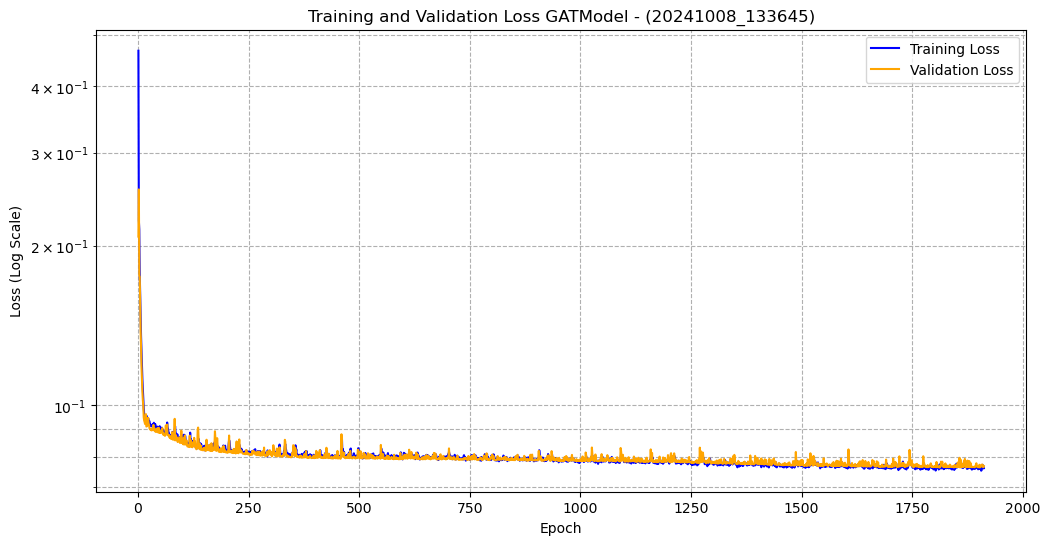

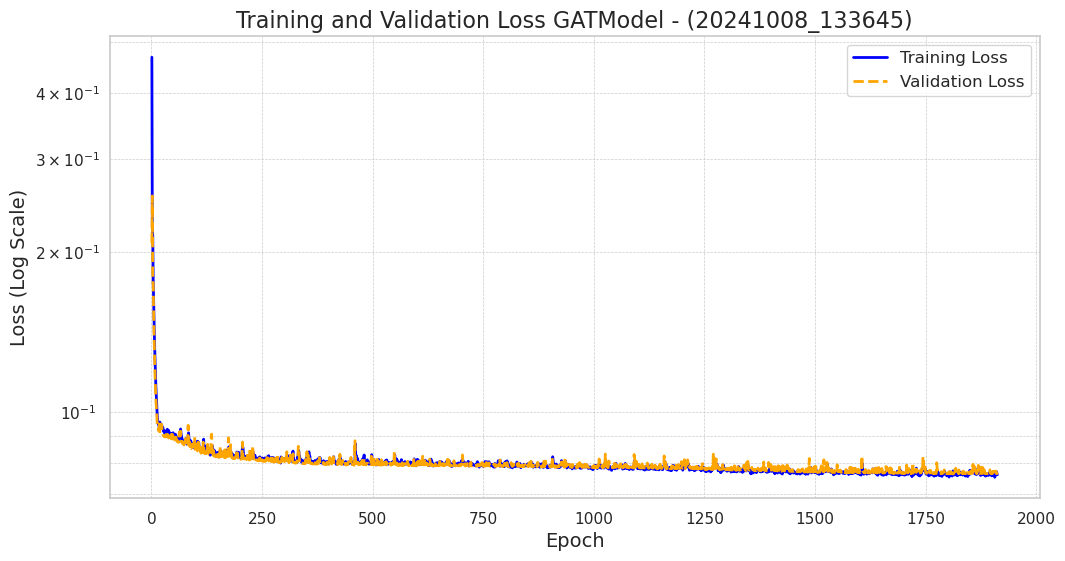

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

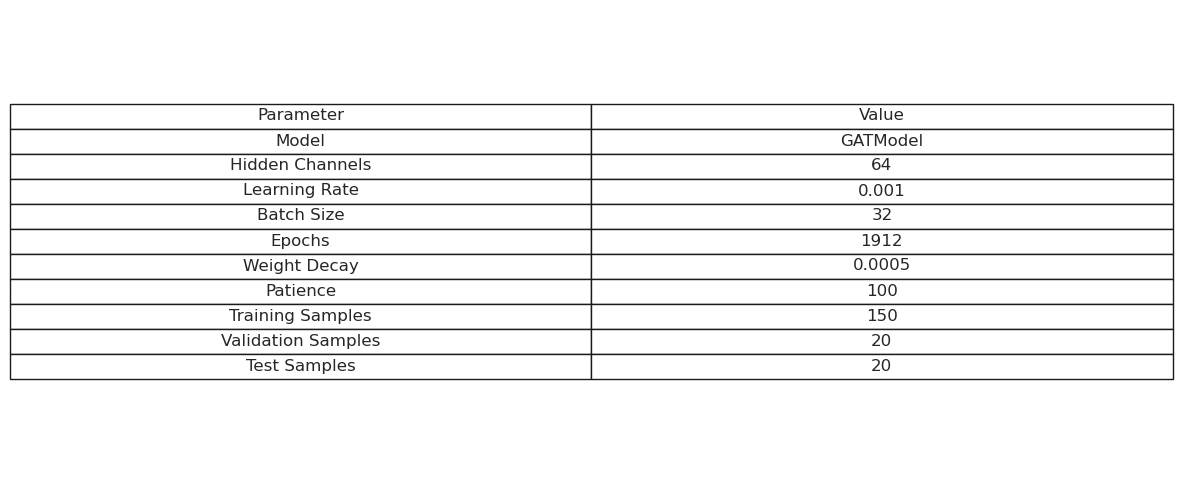


Training Summary:
Total Epochs Run: 1912
Early stopping at epoch 1912
Final Training Loss: 0.076027
Best Validation Loss: 0.076265
Test Loss: 0.074614
Root Mean Squared Error (RMSE): 0.084039
Mean Absolute Error (MAE): 0.029569
R2 Score: 0.769626
Total Training Time: 1250.56 seconds
Data and labels saved successfully.


In [2]:
import os
import time
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import pandas as pd
import datetime
from torch.utils.tensorboard import SummaryWriter
import seaborn as sns

# デバイス設定
if torch.cuda.is_available():
    device = torch.device("cuda:0")
    print(f"GPU is available: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("GPU is not available, using CPU")

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

# データフォルダのパス
standardized_data_folder = "/home/nishioka/GNN/Defect_12x12_data/Defect_12x12_Normalized1"
label_data_folder = "/home/nishioka/GNN/Defect_12x12_data/DefectLabels_12x12test2"

# 座標データのロード
x_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/x_2layer_normalized.npy")[:3654]
y_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/y_2layer_normalized.npy")[:3654]
z_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/z_2layer_normalized.npy")[:3654]

# エッジ情報のロード
edges = np.load("/home/nishioka/GNN/BasicdataforGNN/edges_2layer.npy")
edge_index = torch.tensor(edges.T, dtype=torch.long).to(device)

# データとラベルファイルのリストアップ
data_files = [f for f in os.listdir(standardized_data_folder) if f.startswith("Normalized1_Defect12x12_ELNOD")]
label_files = [f for f in os.listdir(label_data_folder) if f.startswith("12x12DefectLabel1_L")]

# 欠陥なしデータのペア
defect_free_pair = ("/home/nishioka/GNN/Defect_4x4_Normalized1/0Normalized1_nodefect_4x4_ELNOD.npy",
                    "/home/nishioka/GNN/DefectLabels_4x4_test1/0DefectLabel_nodefect1.npy")


# 初期のペアリスト
train_pairs = []
val_pairs = []
test_pairs = []

# 欠陥なしデータを追加
for _ in range(8):
    train_pairs.append(defect_free_pair)
val_pairs.append(defect_free_pair)
test_pairs.append(defect_free_pair)

# ペアのデータをカウントして確認
def count_pair_occurrences(pairs, target_pair):
    return pairs.count(target_pair)

train_count = count_pair_occurrences(train_pairs, defect_free_pair)
val_count = count_pair_occurrences(val_pairs, defect_free_pair)
test_count = count_pair_occurrences(test_pairs, defect_free_pair)

print(f"\nDefect-free data occurrences in train_pairs: {train_count} (expected: 8)")
print(f"Defect-free data occurrences in val_pairs: {val_count} (expected: 1)")
print(f"Defect-free data occurrences in test_pairs: {test_count} (expected: 1)")

if train_count == 8 and val_count == 1 and test_count == 1:
    print("\nAll defect-free data pairs are correctly added.")
else:
    print("\nThere is an issue with adding defect-free data pairs.")

# ファイル名から層とブロックを抽出する関数
def extract_layer_block(file_name):
    if file_name.startswith("0"):
        return (0, 0)  # 欠陥なしデータの場合
    try:
        layer_block_str = file_name.split("_")[-1].replace(".npy", "")
        layer_str = layer_block_str.split("L")[1].split("B")[0]
        block_str = layer_block_str.split("B")[1]
        layer = int(layer_str)
        block = int(block_str)
        return (layer, block)
    except (ValueError, IndexError):
        print(f"無効なファイル名の形式: {file_name}")
        return None

# データとラベルのペアを作成
data_label_pairs = {}
for data_file in data_files:
    layer_block = extract_layer_block(data_file)
    if layer_block:
        data_label_pairs[layer_block] = {"data": data_file}

for label_file in label_files:
    layer_block = extract_layer_block(label_file)
    if layer_block and layer_block in data_label_pairs:
        data_label_pairs[layer_block]["label"] = label_file

# 有効なペアのみ取得
valid_pairs = [(v["data"], v["label"]) for k, v in data_label_pairs.items() if "label" in v]

# ランダムにサンプリング
num_samples = 142
random_indices = np.random.choice(len(valid_pairs), num_samples, replace=False)

# サンプルをトレーニングデータとして取得
sampled_train_pairs = [valid_pairs[i] for i in random_indices]

# 残りのデータを取得
remaining_pairs = [valid_pairs[i] for i in range(len(valid_pairs)) if i not in random_indices]

# 残りのデータを1:1でバリデーションとテストに分割
sampled_val_pairs, sampled_test_pairs = train_test_split(remaining_pairs, test_size=0.5, random_state=42)

# 既存のペアリストにサンプリングされたペアを追加
train_pairs.extend(sampled_train_pairs)
val_pairs.extend(sampled_val_pairs)
test_pairs.extend(sampled_test_pairs)

print(f"\nAfter sampling:")
print(f"Train pairs count (including defect-free): {len(train_pairs)}")
print(f"Validation pairs count (including defect-free): {len(val_pairs)}")
print(f"Test pairs count (including defect-free): {len(test_pairs)}")

# データ準備の関数
def prepare_data(pairs):
    sampled_data = []
    sampled_labels = []
    
    for data_file, label_file in pairs:
        data_file_path = os.path.join(standardized_data_folder, data_file)
        label_file_path = os.path.join(label_data_folder, label_file)

        # データとラベルを読み込む
        values = np.load(data_file_path)[:3654]
        label = np.load(label_file_path)[:3654]
        
        # 座標データと応力データを結合してノード特徴量を作成
        node_features = np.vstack((x_coords, y_coords, z_coords, values)).T
        sampled_data.append(node_features)
        sampled_labels.append(label)
    
    # データを結合しテンソルに変換
    sampled_data = np.stack(sampled_data)  # Shape: (num_samples, 3654, 4)
    sampled_labels = np.stack(sampled_labels)  # Shape: (num_samples, 3654)
    
    # PyTorchテンソルに変換
    x = torch.tensor(sampled_data.reshape(-1, 4), dtype=torch.float).to(device)  # Shape: (num_samples*3654, 4)
    y = torch.tensor(sampled_labels.reshape(-1, 1), dtype=torch.float).to(device)  # Shape: (num_samples*3654, 1)
    
    return x, y

# 各データセットを準備
train_x, train_y = prepare_data(train_pairs)
val_x, val_y = prepare_data(val_pairs)
test_x, test_y = prepare_data(test_pairs)

# Dataオブジェクトにまとめる
train_data_list = []
val_data_list = []
test_data_list = []

# サンプル単位でDataオブジェクトを作成
def create_data_list(x, y, num_samples, data_list):
    for i in range(num_samples):
        start = i * 3654
        end = (i + 1) * 3654
        data = Data(x=x[start:end], edge_index=edge_index, y=y[start:end])
        data_list.append(data)

num_train_samples = len(train_pairs)
num_val_samples = len(val_pairs)
num_test_samples = len(test_pairs)

create_data_list(train_x, train_y, num_train_samples, train_data_list)
create_data_list(val_x, val_y, num_val_samples, val_data_list)
create_data_list(test_x, test_y, num_test_samples, test_data_list)

print(f"\nDataset Sizes:")
print(f"Training data size: {len(train_data_list)} samples")
print(f"Validation data size: {len(val_data_list)} samples")
print(f"Test data size: {len(test_data_list)} samples")

# モデルの定義
class GATModel(nn.Module):
    def __init__(self, hidden_channels=64):
        super(GATModel, self).__init__()
        self.conv1 = GATConv(4, hidden_channels, heads=4, concat=True)  # Input features: 4
        self.conv2 = GATConv(hidden_channels * 4, hidden_channels * 2, heads=4, concat=True)
        self.conv3 = GATConv(hidden_channels * 8, hidden_channels * 4, heads=4, concat=True)
        self.conv4 = GATConv(hidden_channels * 16, hidden_channels, heads=4, concat=True)
        self.conv5 = GATConv(hidden_channels * 4, hidden_channels, heads=1, concat=False)  # 最終層はヘッドを1にしconcat=False
        self.fc_defect = nn.Linear(hidden_channels, 1)  # 回帰タスク用に出力1次元

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = F.relu(self.conv3(x, edge_index))
        x = F.relu(self.conv4(x, edge_index))
        x = F.relu(self.conv5(x, edge_index))
        x = self.fc_defect(x)
        return torch.sigmoid(x)  # バイナリ分類用にSigmoid関数を追加

# Xavier初期化関数
def init_weights(m):
    if isinstance(m, nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
    elif isinstance(m, GATConv):
        if m.lin_src is not None:
            torch.nn.init.xavier_uniform_(m.lin_src.weight)
        if m.lin_dst is not None:
            torch.nn.init.xavier_uniform_(m.lin_dst.weight)

# モデル、損失関数、オプティマイザの定義
hidden_channels = 64
learning_rate = 0.001
batch_size = 32
epochs = 2000
weight_decay = 5e-4
patience = 100  # Early Stopping用

model = GATModel(hidden_channels=hidden_channels).to(device)
model.apply(init_weights)

loss_fn = nn.BCELoss()  # バイナリクロスエントロピー損失
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

# TensorBoardの初期化
writer = SummaryWriter(log_dir=f'/home/nishioka/GNN/Defect_12x12_data/GNNlogs/{timestamp}')

# EarlyStopping クラス定義
class EarlyStopping:
    """Early stopping utility to stop training when validation loss doesn't improve."""
    def __init__(self, patience=patience, verbose=False, delta=0, path='checkpoint.pth', trace_func=print):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.Inf
        self.delta = delta
        self.path = path
        self.trace_func = trace_func

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        if self.verbose:
            self.trace_func(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}). Saving model...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

# EarlyStoppingクラスのインスタンス作成
early_stopping = EarlyStopping(
    patience=patience,
    verbose=True,
    path=f'/home/nishioka/GNN/Defect_12x12_data/GNNmodel/GATModel_best_{timestamp}.pth'
)

# DataLoaderの作成
train_loader = DataLoader(train_data_list, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data_list, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data_list, batch_size=batch_size, shuffle=False)

# 学習ループ
train_losses = []
val_losses = []
start_time = time.time()

print("\n--- Training Start ---")

for epoch in range(1, epochs + 1):
    model.train()
    total_train_loss = 0

    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch)
        loss = loss_fn(out, batch.y.view(-1, 1).float())
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
    
    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # 検証ステップ
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            out = model(batch)
            loss = loss_fn(out, batch.y.view(-1, 1).float())
            total_val_loss += loss.item()
    
    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    # TensorBoardに損失を記録
    writer.add_scalar('Loss/train', avg_train_loss, epoch)
    writer.add_scalar('Loss/val', avg_val_loss, epoch)
    
    # Early Stoppingに現在のバリデーション損失とモデルを渡す
    early_stopping(avg_val_loss, model)
    
    # Early StoppingがTrueなら訓練を終了
    if early_stopping.early_stop:
        print(f"Early stopping at epoch {epoch}")
        break
    
    # 1, 10, 30, 50, 100, 150, 200, 250... のタイミングで結果を出力
    if epoch == 1 or epoch == 10 or epoch == 30 or (epoch % 50 == 0):
        elapsed_time = time.time() - start_time
        print(f'Epoch {epoch}, Train Loss: {avg_train_loss:.6f}, Val Loss: {avg_val_loss:.6f}, Time: {elapsed_time:.2f}s')

# 学習時間の計測終了
elapsed_time = time.time() - start_time
print(f"\nTotal training time: {elapsed_time:.2f} seconds")

# 最良のモデルをロード
model.load_state_dict(torch.load(early_stopping.path))
model.eval()

# テストデータでの評価
test_loss = 0
test_preds = []
test_targets = []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model(batch)
        loss = loss_fn(out, batch.y.view(-1, 1).float())
        test_loss += loss.item()
        test_preds.append(out.cpu().numpy())
        test_targets.append(batch.y.cpu().numpy())

test_loss /= len(test_loader)
test_preds = np.concatenate(test_preds)
test_targets = np.concatenate(test_targets)

# 評価指標の計算
rmse = np.sqrt(mean_squared_error(test_targets, test_preds))
mae = mean_absolute_error(test_targets, test_preds)
r2 = r2_score(test_targets, test_preds)

print(f'\nTest Loss: {test_loss:.6f}, RMSE: {rmse:.6f}, MAE: {mae:.6f}, R2 Score: {r2:.6f}')

# テスト損失をTensorBoardに記録
writer.add_scalar('Loss/test', test_loss, epoch)

# 損失をプロット
plt.figure(figsize=(12, 6))
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss', color='blue')
plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss', color='orange')
plt.yscale('log')  # 対数スケール
plt.xlabel('Epoch')
plt.ylabel('Loss (Log Scale)')
plt.title(f'Training and Validation Loss GATModel - ({timestamp})')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.savefig(f'/home/nishioka/GNN/Defect_12x12_data/GNNmodelgraphfig/loss_fig_GATModel_{timestamp}.png')
plt.show()

sns.set(style="whitegrid")  # テーマ設定

plt.figure(figsize=(12, 6))
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss', color='blue', linewidth=2, linestyle='-')
plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss', color='orange', linewidth=2, linestyle='--')
plt.yscale('log')  # 対数スケール
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss (Log Scale)', fontsize=14)
plt.title(f'Training and Validation Loss GATModel - ({timestamp})', fontsize=16)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.rcParams['font.family'] = 'Arial'  # フォント設定

# 保存
plt.savefig(f'/home/nishioka/GNN/Defect_12x12_data/GNNmodelgraphfig/loss_fig_GATModel_{timestamp}.png')
plt.show()

# パラメータテーブルの作成と保存
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')

# データ
table_data = [
    ["Model", "GATModel"],
    ["Hidden Channels", hidden_channels],
    ["Learning Rate", learning_rate],
    ["Batch Size", batch_size],
    ["Epochs", epoch],
    ["Weight Decay", weight_decay],
    ["Patience", patience],
    ["Training Samples", num_train_samples],
    ["Validation Samples", num_val_samples],
    ["Test Samples", num_test_samples]
]

# テーブルの作成
table = ax.table(cellText=table_data, colLabels=["Parameter", "Value"], loc="center", cellLoc="center")
table.scale(1.5, 1.5)
table.set_fontsize(12)

# 保存
plt.savefig(f'/home/nishioka/GNN/Defect_12x12_data/GNNmodelgraphfig/parameter_table_{timestamp}.png')
plt.show()

# モデルとハイパーパラメータをJSONに保存
model_params = {
    'model': 'GATModel',
    'hidden_channels': hidden_channels,
    'learning_rate': learning_rate,
    'batch_size': batch_size,
    'epochs': epoch,
    'weight_decay': weight_decay,
    'patience': patience
}
with open(f'/home/nishioka/GNN/Defect_12x12_data/GNNmodel/{type(model).__name__}_params_{timestamp}.json', 'w') as f:
    json.dump(model_params, f, indent=4)

# 損失とハイパーパラメータ情報をCSVに保存
loss_data = pd.DataFrame({
    'Epoch': range(1, len(train_losses) + 1),
    'Training Loss': train_losses,
    'Validation Loss': val_losses
})
loss_data.to_csv(f'/home/nishioka/GNN/Defect_12x12_data/GNNmodelcsv/loss_data_{timestamp}.csv', index=False)

# テスト損失の保存
test_loss_data = pd.DataFrame({
    'Test Loss': [test_loss],
    'RMSE': [rmse],
    'MAE': [mae],
    'R2 Score': [r2]
})
test_loss_data.to_csv(f'/home/nishioka/GNN/Defect_12x12_data/GNNmodelcsv/test_loss_{timestamp}.csv', index=False)

# モデルの保存（ファイル名にタイムスタンプを追加）
torch.save(model.state_dict(), f'/home/nishioka/GNN/Defect_12x12_data/GNNmodel/GATModel_final_{test_loss:.6f}_{timestamp}.pth')
torch.save(model.state_dict(), f'/home/nishioka/GNN/Defect_12x12_data/GNNmodelweights/GATModel_weights_{test_loss:.6f}_{timestamp}.pth')

# TensorBoardのWriterを閉じる
writer.close()

# 最終的なサマリーの表示
print("\nTraining Summary:")
print(f"Total Epochs Run: {epoch}")
if early_stopping.early_stop:
    print(f"Early stopping at epoch {epoch}")
else:
    print("Training completed without early stopping.")
print(f"Final Training Loss: {train_losses[-1]:.6f}")
print(f"Best Validation Loss: {early_stopping.val_loss_min:.6f}")
print(f"Test Loss: {test_loss:.6f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.6f}")
print(f"Mean Absolute Error (MAE): {mae:.6f}")
print(f"R2 Score: {r2:.6f}")
print(f"Total Training Time: {elapsed_time:.2f} seconds")

# データの保存
np.save(f'/home/nishioka/GNN/Defect_12x12_data/trainindata_confirm1/train_pairs{type(model).__name__}_{timestamp}.npy', train_pairs)
np.save(f'/home/nishioka/GNN/Defect_12x12_data/trainindata_confirm1/val_pairs{type(model).__name__}_{timestamp}.npy', val_pairs)
np.save(f'/home/nishioka/GNN/Defect_12x12_data/trainindata_confirm1/test_pairs{type(model).__name__}_{timestamp}.npy', test_pairs)

print("Data and labels saved successfully.")

In [7]:
import numpy as np

np.save(f'/home/nishioka/GNN/Defect_12x12_data/trainindata_confirm1/train_pairs{type(model).__name__}_{timestamp}.npy', train_pairs)
np.save(f'/home/nishioka/GNN/Defect_12x12_data/trainindata_confirm1/val_pairs{type(model).__name__}_{timestamp}.npy', val_pairs)
np.save(f'/home/nishioka/GNN/Defect_12x12_data/trainindata_confirm1/test_pairs{type(model).__name__}_{timestamp}.npy', test_pairs)

import matplotlib.pyplot as plt
import seaborn as sns

# matplotlibのフォントをTimes New Romanに設定
plt.rcParams['font.family'] = 'Times New Roman'

# seabornのフォントも同様に設定
sns.set(font='Times New Roman')
